# NLP 2025
# Lab 3: Attention and Pre-trained Models

Our practical journey in NLP has so far covered the following:

🧪 Lab 1: Tokenize and pre-process text in different ways.

🧠 Lab 2: Train different representation models (e.g. TF-IDF) and/or use pre-trained word embeddings with useful applications (such as information retrieval).

🚀 We will now escalate from using pre-trained static word embeddings to use pre-trained models (like BERT). The model is pre-trained on vast amounts of data 📚 and that allows for better generalization. As we discussed in class, BERT models are based on transformers 🤖, which use attention to model sequences (in our case sequences of words).

💡 BERT provides for contextualized embeddings, aka the embedding vector of a word is only determined once the actual context of that word is known. 👉 Practically, this allows for words to have different embedding vectors depending on their actual context (e.g. think of the word "bank" 🏦🏞️ and its multiple meanings in different contexts).

In this lab, we will learn how to load and use pre-trained models (e.g. BERT) from Huggingface 🤗.

By the end of this lab you should be able to:

- 🧠📦Load and/or use pre-trained models and tokenizers to solve different NLP tasks
- 🔍🧬 Inspect and analyze the inner workings (hidden layers etc.) of attention models (like BERT)
- 🧲📝 Use attention models to get sentence representations (aka sentence embeddings)
- 📚🎯 Use BERT sentence embeddings to solve more complicated tasks like information retrieval
- ⚖️📊 Compare performance of different models and assess their effectiveness
- 🛠️🐍 Load and use the basics of pytorch and huggingface transformers (important frameworks in NLP)

### Score breakdown

| Exercise            | Points |
|---------------------|--------|
| [Exercise 1](#e1)   | 1      |
| [Exercise 2](#e2)   | 3      |
| [Exercise 3](#e3)   | 5      |
| [Exercise 4](#e4)   | 2      |
| [Exercise 5](#e5)   | 10     |
| [Exercise 6](#e6)   | 5      |
| [Exercise 7](#e7)   | 10     |
| [Exercise 8](#e8)   | 2      |
| [Exercise 9](#e9)   | 1      |
| [Exercise 10](#e10) | 3      |
| [Exercise 11](#e11) | 10     |
| [Exercise 12](#e12) | 3      |
| [Exercise 13](#e13) | 10     |
| [Exercise 14](#e14) | 10     |
| [Exercise 15](#e15) | 15     |
| [Exercise 16](#e16) | 10     |
| Total               | 100    |

This score will be scaled down to 1 and that will be your final lab score.

### 📌 **Instructions for Delivery** (📅 **Deadline: 2/May 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **PDF of your report** (use the templates provided in **LaTeX** 🖋️ (*preferred*) or **Word** 📑) and a **copy of your notebook** 📓 with the code.
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the report are also visible in your **executed notebook**.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** in the appendix of the report.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

## 0. Setup (Huggingface + PyTorch  = ❤️)

You should know the drill by now. As in the last lab, we will be using huggingface datasets library ([https://huggingface.co/datasets](https://huggingface.co/datasets)). You can find the detailed documentation and tutorials here: [https://huggingface.co/docs/datasets/en/index](https://huggingface.co/docs/datasets/en/index)

If you don't have it installed you can run the code below (if in Google Colab) or copy the code to the terminal (if you run locally):

In [1]:
! pip install -U datasets

  Attempting uninstall: datasets
    Found existing installation: datasets 3.5.0
    Uninstalling datasets-3.5.0:
      Successfully uninstalled datasets-3.5.0

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Next, we will need [PyTorch](https://pytorch.org/) installed. It is a very popular deep learning library that offers modularized versions of many of the sequence models we discussed in class. It's an important tool that you may want to practice further if you want to dive deeper into NLP, since much of the current academic and industrial research uses it.

Some resources to look further are given below.

* [Documentation](https://pytorch.org/docs/stable/index.html) (We will need this soon)

* [Installation Instructions](https://pytorch.org/get-started/locally/)

* [Quickstart Tutorial](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html)

The cell below should install the library:

In [2]:
! pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 14.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 14.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0
    Uninstalling torch-2.6.0:
      Successfully uninstalled torch-2.6.0

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


The last bit we need is the huggingface transformers library (here is the documentation [https://huggingface.co/docs/transformers/en/index](https://huggingface.co/docs/transformers/en/index)). Transformers are one of the most influential architectures in handling sequences (not only in language). As we discussed in lectures, they excel at taking into account context (which is the salt-and-pepper of NLP) with mechansisms such as self-attetion, which allows them to weigh the importance of different words in a sentence. If you want to know more, revisit the course material (slides and textbook).

We already used huggingface datasets in previous labs and huggingface transformers integrates nicely with that. Apart from the ease of use, huggingface is also providing pre-trained models of different kinds. The list can be found [here](https://huggingface.co/models) ([https://huggingface.co/models](https://huggingface.co/models)). The following line should be enough to install huggingface transformers library:

In [3]:
! pip install transformers


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


As usual, we start by importing some essential Python libraries that we will be using.

In [5]:
import math

from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import datasets
import transformers
import tqdm
import torch

## 1. Load and Preprocess Data

For easiness and comparison purposes, we will ue the same dataset as in the previous lab. That will help us re-visit the approach and see whether contextualized architectures can do better in the same problem/task/dataset.

As a reminder:

*Sentence compression* involves rephrasing sentences to make them shorter while still retaining the original meaning. A reliable compression system would be valuable for mobile devices and could also serve as a component in an extractive summarization system.

The dataset we are going to use can be found on [Huggingface](https://huggingface.co/datasets/embedding-data/sentence-compression). It concerns a set of 180,000 pairs of sentences, aka it is a parallel corpus of sentences and their equivalent compressions. It has been collected by harvesting news articles from the Internet where the headline appears to be similar to the first sentence and that property is used to find an "extractive" compression of the sentence.

For example, for the sentence

`"Regulators Friday shut down a small Florida bank, bringing to 119 the number of US bank failures this year amid mounting loan defaults"`

the compressed equivalent (based on the dataset) is:

`"Regulators shut down small Florida bank"`.


For more information you can read the original paper (from Google) [here](https://aclanthology.org/D13-1155.pdf).

### 1.1 Loading the Dataset

The dataset will be loaded as a huggingface datgaset. This may take a few minutes because of the large size of the data.

Make sure to inspect the dataset and make sure it is imported properly.

In [6]:
ds = datasets.load_dataset('embedding-data/sentence-compression')
print(ds)

DatasetDict({
    train: Dataset({
        features: ['set'],
        num_rows: 180000
    })
})


In [7]:
for i in range(10):
    print(ds['train'][i])

{'set': ["The USHL completed an expansion draft on Monday as 10 players who were on the rosters of USHL teams during the 2009-10 season were selected by the League's two newest entries, the Muskegon Lumberjacks and Dubuque Fighting Saints.", 'USHL completes expansion draft']}
{'set': ['Major League Baseball Commissioner Bud Selig will be speaking at St. Norbert College next month.', 'Bud Selig to speak at St. Norbert College']}
{'set': ["It's fresh cherry time in Michigan and the best time to enjoy this delicious and nutritious fruit.", "It's cherry time"]}
{'set': ['An Evesham man is facing charges in Pennsylvania after he allegedly dragged his girlfriend from the side of his pickup truck on the campus of Kutztown University in the early morning hours of Dec. 5, police said.', 'Evesham man faces charges for Pa.']}
{'set': ["NRT LLC, one of the nation's largest residential real estate brokerage companies, announced several executive appointments within its Coldwell Banker Residential B

The dataset comes with a `train` split so we will have to split that into `train`/`test` ourselves with the line below.

In [8]:
split_ds = ds['train'].train_test_split(test_size=0.2)
print(split_ds)

DatasetDict({
    train: Dataset({
        features: ['set'],
        num_rows: 144000
    })
    test: Dataset({
        features: ['set'],
        num_rows: 36000
    })
})


Note that previously, we had very much full control over the vocabulary of the dataset (in terms of pre-processing including tokenization). That is because we wanted to build our own embedding model.

By using a *pre-trained* model (like we are going to do at this lab), we need to adhere to the way this model was trained (including the tokenization). Huggingface provides the models, along with the relevant tokenizers, therefore cleaning is not necessary (as in previous labs). You can still include it if you think this would improve the results of the retrieval in the later parts of the lab.

<a name='e1'></a>
### Exercise 1 Unpacking the set
(1p) Instead of cleaning, we will unpack the `set` (containing tuples of full and compressed sentences) column into separate `sentence` and `compressed` columns. This will make it a bit easier for us later.

One key difference in this function is the fact that it will accept a batch of examples (instead of a single example in the exercises in the previous lab). You can iterate through the examples this way:

```
for set in examples['set']
```

The new columns should be lists containing strings (full or compressed sentences) extracted from the `set` column.

Fill in the function below to complete this task

In [9]:
def unpack(examples):
    """
    Unpacks the column `set` into two columns `sentence` and `compressed`.
    Args:
        examples: a batch of examples from the dataset

    Returns: modified examples with two new columns: `sentence` and `compressed`

    """
    sentences = []
    compressed_sentences = []

    ### YOUR CODE HERE

    for set in examples['set']:
        sentences.append(set[0])
        compressed_sentences.append(set[1])
    
    ### YOUR CODE ENDS HERE

    examples['sentence'] = sentences
    examples['compressed'] = compressed_sentences
    return examples

In the next cell, we will apply the `unpack` function to the whole dataset. Notice that we also drop the original `set` column.

In [10]:
split_ds = split_ds.map(unpack, batched=True, remove_columns=['set'])
print(split_ds)

Map:   0%|          | 0/144000 [00:00<?, ? examples/s]

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'compressed'],
        num_rows: 144000
    })
    test: Dataset({
        features: ['sentence', 'compressed'],
        num_rows: 36000
    })
})


Let's examine some examples from the dataset and make sure that we got the results we wanted.

In [109]:
for i in range(10):
    print(split_ds['train'][i])

{'sentence': 'A 19-year-old Glenwood man died Saturday after being run over by a wagon at the Southeast Purdue Ag Center in Butlerville.', 'compressed': 'Man dies after being run over by wagon'}
{'sentence': "Mitsubishi Heavy Industries, Tokyo, has been assigned a patent developed by six co-inventors for an ``integrated gasification combined cycle power generation plant.''", 'compressed': 'Mitsubishi Heavy Industries assigned patent'}
{'sentence': 'Pitching carries Yankees past Rockies With so many New York front-line players on the disabled list, run production has become a concern for the Yankees.', 'compressed': 'Pitching carries Yankees past Rockies'}
{'sentence': 'Minister for Welfare of Scheduled Tribes PK Jayalekshmi has denied allegations of nepotism in the appointment of tribal promoters for various welfare schemes implemented by the Scheduled Tribes Development Department.', 'compressed': 'Minister denies allegations'}
{'sentence': 'The Vienna Philharmonic Orchestra, one of t

In this lab, we will be using only pre-trained models. That means that we won't be training any new model. This is the reason we can select only the `test` subset for the rest of the notebook (this is where we will be assessing the performance of the pre-trained models). At the same time, we will save much time, as we will not be processing the `train` subset.

In [15]:
test_ds = split_ds['test']
print(test_ds)

Dataset({
    features: ['sentence', 'compressed'],
    num_rows: 36000
})


### 1.2 Loading the Tokenizer

For the first part of this lab, we will be using a pre-trained BERT model from Huggingface, namely the [BERT Uncased](https://huggingface.co/google-bert/bert-base-uncased). You can read the original paper that introduced this model [here](https://aclanthology.org/N19-1423.pdf). This paper has been once of the most cited papers ever (currently having more than 100,000 citations).

We will specify the model name that can be found on the model's card on huggingface (revisit the first link). Make sure to check what other information Huggingface is offering (e.g. how to use the model, limitations, how to inference, etc.).

In [16]:
model_name = 'google-bert/bert-base-uncased'

The models on huggingface come with their own tokenizers. They are loaded separately from the models. We can use [AutoTokenizer](https://huggingface.co/docs/transformers/v4.40.2/en/model_doc/auto#transformers.AutoTokenizer)'s `from_pretrained()` method to load it.

Inspect the output: The loaded object is of `BertTokenizerFast` class. Check the documentation [here](https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertTokenizerFast).

In [91]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
print(tokenizer)

tokenizer_config.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='sentence-transformers/msmarco-bert-base-dot-v5', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


Next, let's see how we can use it to tokenize some text.

In [19]:
print(test_ds[0]['sentence'])
tokenized = tokenizer(test_ds[0]['sentence'], padding=True, return_tensors='pt')
print("---")
print(type(tokenized))
print("---")
print(tokenized)

A high-ranking Russian parliamentary official says Moscow is opposed to imposing unilateral sanctions against Iran over its nuclear energy program.
---
<class 'transformers.tokenization_utils_base.BatchEncoding'>
---
{'input_ids': tensor([[  101,  1037,  2152,  1011,  5464,  2845,  5768,  2880,  2758,  4924,
          2003,  4941,  2000, 16625,  4895, 11733, 14621,  2140, 17147,  2114,
          4238,  2058,  2049,  4517,  2943,  2565,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1]])}


Examine the outputs: The tokenizer returned three things:
- `input_ids` - this is a PyTorch tensor ([https://pytorch.org/docs/stable/tensors.html](https://pytorch.org/docs/stable/tensors.html)) with the indices of our tokens. PyTorch tensors are similar to numpy arrays. They hold data in a multidimensional array or matrix. The difference is that PyTorch tensors can be placed and modified on the GPU which greatly improves the speed of execution.
- `token_type_ids` - this tensor holds the information about the index of the sentence. This has to do with the classification objective from the original paper, where two sentences were given and the model had to predict if they are connected. Because we only included a single sentence, we have only zeros here. We will not be concerned with it in this lab.
- `attention_mask` - holds the mask that the model will use to determine if the tokens in the `input_ids` are the real tokens or *padding*. Padding is a technique used to ensure that all input sequences have the same length. BERT (like many other NLP models) process data in batches and requires each sequence in a batch to have the same length, so sequences that are shorter than the maximum sequence length in the batch are padded with special tokens. In this case, because we only inputted a single sentence, the mask contains only ones. Later you will see examples where this is not the case.

Let's see how exactly the sentence was tokenized and how we can retrieve the original text. Notice that some words have been split into multiple tokens (remember when we discussed sub-word tokenization in class?). Also pay attention to the added special tokens, namely `CLS` and `SEP`:

The `[CLS]` token is a special classification token added at the beginning of every input sequence. It stands for "classification" (daah!) and is used by BERT to aggregate information from the entire sequence. The final hidden state corresponding to this token (after passing through the transformer layers) is used as the aggregate sequence representation for classification tasks. We will use this later in the lab!

The `[SEP]` token is used to separate different segments or sentences within the input sequence. It stands for "separator" (daaah again!).

In [20]:
print(tokenized['input_ids'].shape)
print("---")
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0]))
print("---")
print(len(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0]))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=True))

torch.Size([1, 28])
---
['[CLS]', 'a', 'high', '-', 'ranking', 'russian', 'parliamentary', 'official', 'says', 'moscow', 'is', 'opposed', 'to', 'imposing', 'un', '##ila', '##tera', '##l', 'sanctions', 'against', 'iran', 'over', 'its', 'nuclear', 'energy', 'program', '.', '[SEP]']
---
28
---
[CLS] a high - ranking russian parliamentary official says moscow is opposed to imposing unilateral sanctions against iran over its nuclear energy program. [SEP]
---
a high - ranking russian parliamentary official says moscow is opposed to imposing unilateral sanctions against iran over its nuclear energy program.


Tokenizer can process a list of sentences. This will create a batched output with tensor's first dimension corresponding to the batch size (the number of sentences we passed to the tokenizer). Examine the following cell and make sure it makes sense to you.

In [23]:
print(test_ds[0:3]['sentence'])
tokenized = tokenizer(test_ds[0:3]['sentence'], padding=True, return_tensors='pt')
print(tokenized)
print(tokenized['input_ids'].shape)
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0]))
print(len(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])))
print(tokenizer.decode(tokenized['input_ids'][0]))
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=True))

['A high-ranking Russian parliamentary official says Moscow is opposed to imposing unilateral sanctions against Iran over its nuclear energy program.', 'A former Great Falls mayor who pleaded no contest to prostitution-related and obstruction charges says he will appeal the one-year jail sentence he received earlier this month.', "Michael C. Hall married his co-star on the show Jennifer Carpenter in a New Year's Eve ceremony."]
{'input_ids': tensor([[  101,  1037,  2152,  1011,  5464,  2845,  5768,  2880,  2758,  4924,
          2003,  4941,  2000, 16625,  4895, 11733, 14621,  2140, 17147,  2114,
          4238,  2058,  2049,  4517,  2943,  2565,  1012,   102,     0,     0,
             0,     0,     0,     0],
        [  101,  1037,  2280,  2307,  4212,  3664,  2040, 12254,  2053,  5049,
          2000, 15016,  1011,  3141,  1998, 27208,  5571,  2758,  2002,  2097,
          5574,  1996,  2028,  1011,  2095,  7173,  6251,  2002,  2363,  3041,
          2023,  3204,  1012,   102],
    

<a name='e2'></a>
### Exercise 2 Questions about the tokenizer

Answer the following questions:
- (1p) What is the size of the vocabulary?
- (2p) What are the special tokens apart from `[CLS]` and `[SEP]`? What are their functions?

In [116]:
tokenizer

BertTokenizerFast(name_or_path='google-bert/bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

The vocabulary size is 30522, including all the special tokens.

Apart from [CLS] and [SEP], there are 3 other special tokens: [PAD], [UNK] and [MASK]
- [UNK] replaces all the rare, OOV words in the dataset. So if a word in the input is not recognized, it is tokenized as [UNK]
- [PAD] is padding to keep sentence length constant during training
- [MASK] is used during the pretraining of the BERT model. Tokens in the training data are randomly replaced with [MASK] and the model is optimized be able to better predict/reconstruct the original token based on its context.


### 1.4 Loading the Model

In this section, we will load and examine the model. We will start with selecting the device we will place the model on. This will be a GPU (if one is available) or a CPU.

Google Colab offers free access to GPU, provided there is availability (also baed on quotas which may vary based on your usage and the overall demand on Colab's resources). If you are working locally, then if you don't have a GPU, CPU will be selected. For the first parts of the assignment running on CPU might be okay but when we have to load the dataset a GPU will be necessary.

The following cell will select the device for us.

In [38]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


Now, let's load the model from huggingface and place it (slowly because it's heavy due to the large number of parameters) on the device from the previous cell (the methods `to()`).

In [39]:
pip install hf_xet

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
model = transformers.AutoModel.from_pretrained(model_name)
model.to(device)
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

<a name='e3'></a>
### Exercise 3 Questions about the Model

Examine the output of the previous cells. Answer the following questions:
- (1p) What is the number of transformer layers in this model?
- (1p) What is the dimension of the embeddings?
- (1p) What is the hidden size of the FFN in the transformer layer?
- (1p) What is the total number of parameters of the model (hint: check the `num_parameters()` method of the model)?
- (1p) How can you find the vocabulary size from the model?

There are 12 transformer layers in this model

The dimension of the embeddings is 768

The hidden size of the FFN in the transformer layer is 3072

The total number of parameters of the model is 109,482,240

You can find the vocabulary size of the model by looking at the shape of the "word_embeddings" tensor. In this case it is (30522, 768) so the vocabulary size is 30522 and the embedding dimension is 768

In [41]:
model.num_parameters()

109482240

In [42]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

Next, let's use BERT model for inference. We will tokenize the first sentence of our dataset and pass it to the model. We set `output_hidden_states` to `True` in order to have access to the hidden states of the model. Those represent the latent representations after embedding and transformer layers.

In [43]:
tokenized = tokenizer(test_ds[0]['sentence'], padding=True, return_tensors='pt').to(device)
print(tokenized)
model_output = model(**tokenized, output_hidden_states=True)

{'input_ids': tensor([[  101,  1037,  2152,  1011,  5464,  2845,  5768,  2880,  2758,  4924,
          2003,  4941,  2000, 16625,  4895, 11733, 14621,  2140, 17147,  2114,
          4238,  2058,  2049,  4517,  2943,  2565,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1]])}


Examine the next cell and make sure everything makes sense to you. Consult the [documentation](https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertModel.forward) in case of doubt.

In [44]:
print(list(model_output.keys()))
print(type(model_output['pooler_output']))
print(model_output['pooler_output'].shape)
print(type(model_output['hidden_states']))
print(len(model_output['hidden_states']))
print(type(model_output['hidden_states'][0]))
print(model_output['hidden_states'][0].shape)

['last_hidden_state', 'pooler_output', 'hidden_states']
<class 'torch.Tensor'>
torch.Size([1, 768])
<class 'tuple'>
13
<class 'torch.Tensor'>
torch.Size([1, 28, 768])


## 2. Exploring BERT hidden states

In this section we will look in more detail into the embeddings (latent representations) of BERT model. As a reminder, BERT embeddings a type of contextual word embeddings generated by the BERT model. They capture the meaning of words in the actual context. Notice the contrast with the static word embeddings we worked with in the previous lab: Then, we only needed a large corpus to compute word embeddings. In the case of BERT, we need to pass the actual sequence through the model to get the equivalent vector. More specifically, we tokenize the sentence (based on the relevant model and tokenizer), add the special tokanes (`CLS` and `SEP`, which are added authomatically by the tokenizer) and pass the sentence in the model.

<a name='e4'></a>
### Exercise 4 Plotting the layer-wise similarities between words 

(2p) We will use the following function to plot the cosine similarity between tokens in different sentences. It takes `hidden_states` and `tokens_of_interest_ids` arguments. The `hidden_states` is a list of Tensors and contains the hidden states of the sentences. The size of the list is equal to the number of layers in the model (+1 for the initial embedding) and each element is a Tensor with the first dimension corresponding to the sentences in the batch and second to the tokens (see the previous code cell). The third dimension is the size of the embedding. The `tokens_of_interest_ids` is a list of integers of the size equal to the number of sentences. The integers are indices that identify tokens we want to compare with each other.

Fill in the function by first extracting the embeddings of the token-of-interest in a `layer` for two sentences `sent1` and `sent2`. Next, calculate the cosine similarity between the embeddings. You can use an existing PyTorch implementation of cosine similarity.

In [45]:
from typing import List
from itertools import combinations


def plot_evolving_similarities(hidden_states: List[torch.Tensor], tokens_of_interest_ids: List[int]):
    """
    Plots the evolving cosine similarity between the hidden representation of tokens in different sentences.
    Hidden states are provided as a list of tensors where each tensor corresponds to the layer of the model.
    Each tensor contains the hidden representations of each token (second dimension) of each sentence (first dimension).
    For each sentence there have to be a token of interest (can be the same).
    Args:
        hidden_states: a list of tensors containing the hidden representations of sentences
        tokens_of_interest_ids: a list of indices of tokens of interest
    """
    assert hidden_states[0].shape[0] == len(tokens_of_interest_ids), \
        'The batch size of hidden_states must be equal to the number of tokens of interest'

    num_layers = len(hidden_states)
    num_sentences = len(tokens_of_interest_ids)
    # Creates a list of all possible combinations of sentences
    sentence_combinations = list(combinations(range(num_sentences), 2))
    similarities = [[] for _ in range(len(sentence_combinations))]
    for layer in range(num_layers):
        for i, (sent1, sent2) in enumerate(sentence_combinations):

            ### YOUR CODE HERE
            # 1. Extract embeddings for the tokens of interest in the current layer for sent1 and sent2
            # 2. Compute the cosine similarity between the two embeddings

            sent1_state = hidden_states[layer][sent1][tokens_of_interest_ids[sent1]]
            sent2_state = hidden_states[layer][sent2][tokens_of_interest_ids[sent2]]

            dot_product = torch.dot(sent1_state, sent2_state)

            # Compute magnitudes
            norm_1 = torch.norm(sent1_state)
            norm_2 = torch.norm(sent2_state)

            # Compute cosine similarity
            cosine_similarity = dot_product / (norm_1 * norm_2)

            ### YOUR CODE ENDS HERE
            
            similarities[i].append(cosine_similarity.detach().numpy())

    for i, (sent1, sent2) in enumerate(sentence_combinations):
        plt.plot(range(num_layers), similarities[i],
                 label=f'between {sent1 + 1} and {sent2 + 1}')
    plt.xlabel('layer')
    plt.ylabel('cosine similarity')
    plt.legend()
    plt.show()

Here are three sentences with the word "bank". The word form is the same for all, however the meaning is different in the second sentence. Remember polysemy?

We can plot how the cosine similarity between the embeddings (and latent representations) of the word "bank" in each sentence evolves through the different layers of BERT.

The following code follows the procedure we described above.

{'input_ids': tensor([[  101,  2057,  2097,  6487,  1037,  2924,  2279,  2733,   999,   102,
             0,     0,     0],
        [  101,  1996,  2336, 16791,  6386,  2011,  1996,  2924,  1997,  1996,
          2314,  1012,   102],
        [  101,  1045,  2404,  2769,  1999,  1996,  2924,  1012,   102,     0,
             0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]])}
['[CLS]', 'we', 'will', 'rob', 'a', 'bank', 'next', 'week', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'the', 'children', 'skipped', 'stones', 'by', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']
['[CLS]', 'i', 'put', 'money', 'in', 'the', 'bank', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
bank
bank


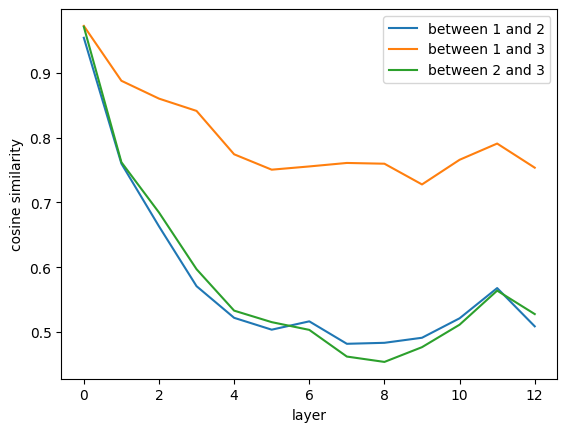

In [46]:
text1 = "We will rob a bank next week!"
text2 = "The children skipped stones by the bank of the river."
text3 = "I put money in the bank."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
print(tokenized)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [5, 7, 6]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

<a name='e5'></a>
### Exercise 5 Evolution of embeddings

- (3p) Discuss the plots above. Are the plots showing what you expected to see?
- (1p) Take a look at the similarity between the word "bank" in the first example for the first layer (layer index 0)? This corresponds to the embedding layer of BERT. It is close to `1` but not exactly. Why is that?
- (3p) Plot and analyze the similarities between words "nice", "bad", and "lovely" in the sentences "The weather is nice today.", "The weather is bad today.", and "The weather is lovely today.". Comment on the results. Are the plots showing what you expected to see? 
- (3p) Try a different set of sentences and comment on the results.

The plots are indeed show what we'd expect to see. Across all sentences, activations for "bank" between sentence 1 and 3 are most similar because the word "bank" is used in the same way in both sentences. That is, meaning "financial establishment". In sentence 2, the word "bank" is used in a different sense as "land alongside a river or lake". Thus, the activations of "bank" in sentence 2 have lower similarity to that in sentences 1 and 2.

This is due to the effect of adding positional embeddings to each word embedding to represent the order of the words in the sentence. Since the position index of the word "bank" is different in all 3 sentences (idx=[5,7,6]) the positional embeddings are also different.

{'input_ids': tensor([[ 101, 1996, 4633, 2003, 3835, 2651, 1012,  102],
        [ 101, 1996, 4633, 2003, 2919, 2651, 1012,  102],
        [ 101, 1996, 4633, 2003, 8403, 2651, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1]])}
['[CLS]', 'the', 'weather', 'is', 'nice', 'today', '.', '[SEP]']
['[CLS]', 'the', 'weather', 'is', 'bad', 'today', '.', '[SEP]']
['[CLS]', 'the', 'weather', 'is', 'lovely', 'today', '.', '[SEP]']
nice
bad
lovely


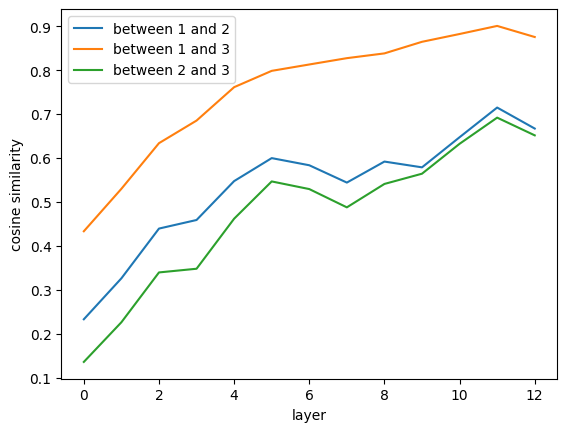

In [47]:
text1 = "The weather is nice today."
text2 = "The weather is bad today."
text3 = "The weather is lovely today."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
print(tokenized)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [4, 4, 4]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

The results are as expected. The highest similarity is between the synonyms "nice" and "lovely" across sentences 1 and 3 while the similarity of ("nice" ,"bad) and ("lovely", "nice") is noticeably lower across all layers)

{'input_ids': tensor([[  101,  2017,  2031,  2000,  2422,  1996, 19976,   102,     0,     0,
             0,     0,     0],
        [  101,  2106,  2017,  2422,  1996,  2674,  1029,   102,     0,     0,
             0,     0,     0],
        [  101,  2821,  2123,  1005,  1056,  4737,  1010,  1996,  4524,  2003,
          3243,  2422,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
['[CLS]', 'you', 'have', 'to', 'light', 'the', 'fuse', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'did', 'you', 'light', 'the', 'match', '?', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'oh', 'don', "'", 't', 'worry', ',', 'the', 'bag', 'is', 'quite', 'light', '[SEP]']
light
lig

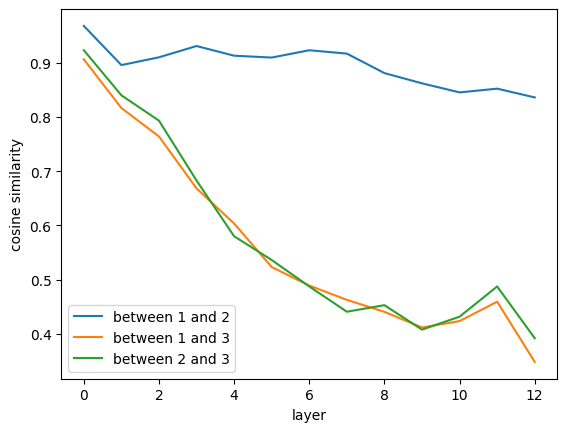

In [48]:
text1 = "You have to light the fuse"
text2 = "Did you light the match?"
text3 = "Oh don't worry, the bag is quite light"
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
print(tokenized)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [4, 3, 11]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

For this exercise we looked at the sentences where the word "light" is used in two different ways. One meaning of the word "light" is as a verb meaning "to ignite" and another is "light" in the sense of "weighing little". The sentences we used are:

As with "bank", the two sentences where "light" is used in the same way maintain the highest similarity.

## 3. Calculating BERT sentence embeddings

It is finally time to use BERT's hidden states as word embeddings. First, you will write a function to aggregate the BERT's hidden representations of the words in a sentence.

<a name='e6'></a>
### Exercise 6 Implement sentence embeddings

(5p) Implement the following function. It will receive the batched input to the model and its output. Calculate the mean embedding of the tokens in each sentence. In particular, get `attention_mask` from the `input_batch` and `hidden_states` from `model_output` (already done for you), and calculate the mean of the hidden states. Remember that you are working with a batch, so both `attention_mask` and `hidden_states` contain multiple sentences (the first dimension of both tensors correspond to the size of the batch). In the end, you should have a tensor with a shape batch_size x embedding_size.

Pay attention to the padded tokens (indicated by the attention mask from the input).

Additionally, the function will receive the `layer` parameter. It will indicate the index of the layer of which the hidden representations of tokens will be aggregated. The default value of `-1` indicates the last layer. The code already selects the hidden states of the specified layer.

Optionally, you can ignore the special tokens `[CLS]` and `[SEP]`.

In [49]:
def calculate_sentence_embeddings(input_batch, model_output, layer=-1):
    """
    Calculates the sentence embeddings of a batch of sentences as a mean of token representations.
    The representations are taken from the layer of the index provided as a `layer` parameter.
    Args:
        input_batch: tokenized batch of sentences (as returned by the tokenizer), contains `input_ids`, `token_type_ids`, and `attention_mask` tensors
        model_output: the output of the model given the `input_batch`, contains `last_hidden_state`, `pooler_output`, `hidden_states` tensors
        layer: specifies the layer of the hidden states that are used to calculate sentence embedding

    Returns: tensor of the averaged hidden states (from the specified layer) for each example in the batch

    """
    attention_mask = input_batch['attention_mask']
    hidden_states = model_output['hidden_states'][layer]

    ### YOUR CODE HERE

    sentence_embeddings = []

    # sanity check
    assert input_batch['input_ids'].shape[0] == len(model_output['hidden_states'][layer])

    num_sentences = input_batch['input_ids'].shape[0]
    
    for i in range(num_sentences):
        
        mask = attention_mask[i]

        # Build a mask that excludes [CLS] and [SEP] tokens (IDs 101 and 102)
        # Also use attention_mask to exclude [PAD] tokens
        exclude_mask = (input_batch['input_ids'][i] != 101) & (input_batch['input_ids'][i] != 102) & (mask == 1)

        # Apply the mask
        valid_token_embeddings = hidden_states[i][exclude_mask]
        
        # DEBUGGING stuff
        # print(hidden_states[i])
        # print(hidden_states[i].shape)
        # print(valid_token_embeddings)
        # print(valid_token_embeddings.shape)
        # print("===========================")
        #valid_token_embeddings = hidden_states[i]
        
        sentence_embeddings.append(valid_token_embeddings.mean(dim=0))

    sentence_embeddings = torch.stack(sentence_embeddings, dim=0)

    ### YOUR CODE ENDS HERE


    return sentence_embeddings

Let us try out the function.

In [50]:
text = "The weather is nice today."
tokenized = tokenizer(text, padding=True, return_tensors='pt').to(device)
print(tokenized)
model_output = model(**tokenized, output_hidden_states=True)
print(model_output['last_hidden_state'].shape)
sentence_embedding = calculate_sentence_embeddings(tokenized, model_output)
print(sentence_embedding.shape)

{'input_ids': tensor([[ 101, 1996, 4633, 2003, 3835, 2651, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}
torch.Size([1, 8, 768])
torch.Size([1, 768])


The following function will plot the evolution of cosine similarities between sentence embeddings based on representations of different layers of the model.

Notice that it will receive a function that is used to calculate the sentence embeddings (that is the function we implemented above).

In [51]:
def plot_evolving_sentence_similarities(input_batch, model_outputs, sentence_embeddings_fn):
    num_layers = len(model_outputs['hidden_states'])
    num_sentences = input_batch['input_ids'].shape[0]
    sentence_combinations = tuple(combinations(range(num_sentences), 2))
    similarities = [[] for _ in range(len(sentence_combinations))]

    for layer in range(num_layers):
        sentence_embeddings = sentence_embeddings_fn(input_batch, model_outputs, layer)
        for i, (sent1, sent2) in enumerate(sentence_combinations):
            embedding1 = sentence_embeddings[sent1]
            embedding2 = sentence_embeddings[sent2]
            cosine_similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2, dim=0)
            similarities[i].append(cosine_similarity.detach().cpu().numpy())

    for i, (sent1, sent2) in enumerate(sentence_combinations):
        plt.plot(range(num_layers), similarities[i], label=f'between {sent1 + 1} and {sent2 + 1}')

    plt.xlabel('layer')
    plt.ylabel('cosine similarity')
    plt.legend()
    plt.show()


Let's examine the cosine similarities of the sentences with the word "bank" from earlier.

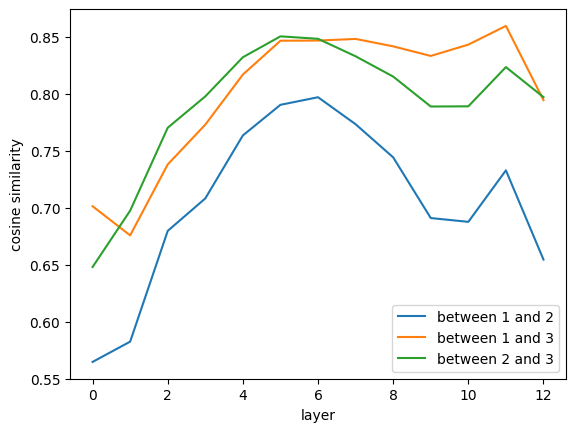

In [52]:
text1 = "We will rob a bank next week!"
text2 = "Let's put our savings into a bank account."
text3 = "We will steal some money from the bank."

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

<a name='e7'></a>
### Exercise 7 Try different sentences

(10p) Try out your sentence embeddings on at least two different sets of sentences. Inspect the results in terms of the different layers. Comment on the results. Are they expected?

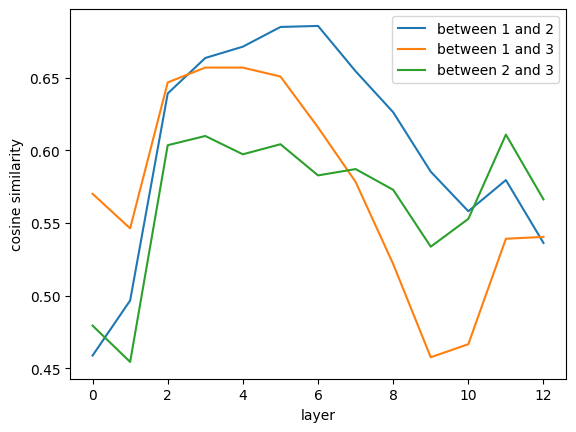

In [53]:
text1 = "I'm dying, man. It's too much!"
text2 = "This is very funny"
text3 = "I was admitted to the ER"

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

Theses sentences reveal how the network gets better at understanding the meaning and context of a sentence as you step through its layers.  To a human, the first sentence may at first seem to be about literal dying but on closer inspection most would see that it is plausibly just someone using hyperbole to express that something is funny. The plot depicts this same dynamic since for the first few layers, sentence 1 is considered most similar to sentence 3 (related to mortality) but in later layers, as the model processes the sentence further, it  becomes most similar to sentence 2 (related to humour).

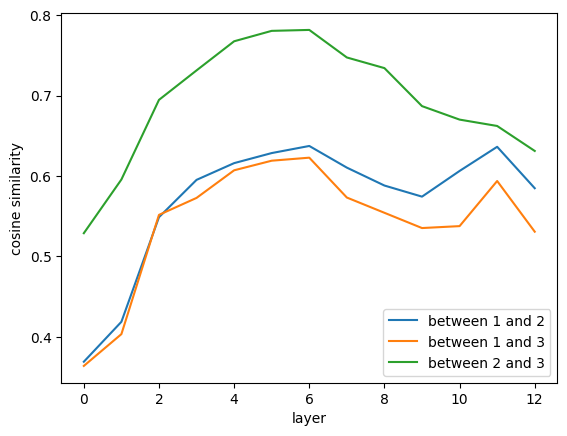

In [54]:
text1 = "We will have to stay indoors"
text2 = "It is raining"
text3 = "The weather is sunny"

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

It can be seen that the similarity of sentences 2 and 3 is the highest, probably because they both directly reference weather. This is despite the fact that the two sentences contradict each other. This underscores that this method of sentence embedding does not always match human intuitions about similarity.

### 3.1 Applying BERT sentence embeddings

Next, we will be calculating the word embeddings on our dataset. This is the moment where having GPU will greatly speed up the computations but fast CPU should do just fine (you might have to wait couple of minutes for embedding the whole dataset).

As mentioned before, we can use Google Colab [https://colab.google/](https://colab.google/) for this purpose. It gives you access to a GPU for a limited time (after you used this time you will have to wait for some time to use it again). To use a GPU you need to select the runtime type. Go to "Runtime -> Change runtime type". There you can select a CPU or a GPU.

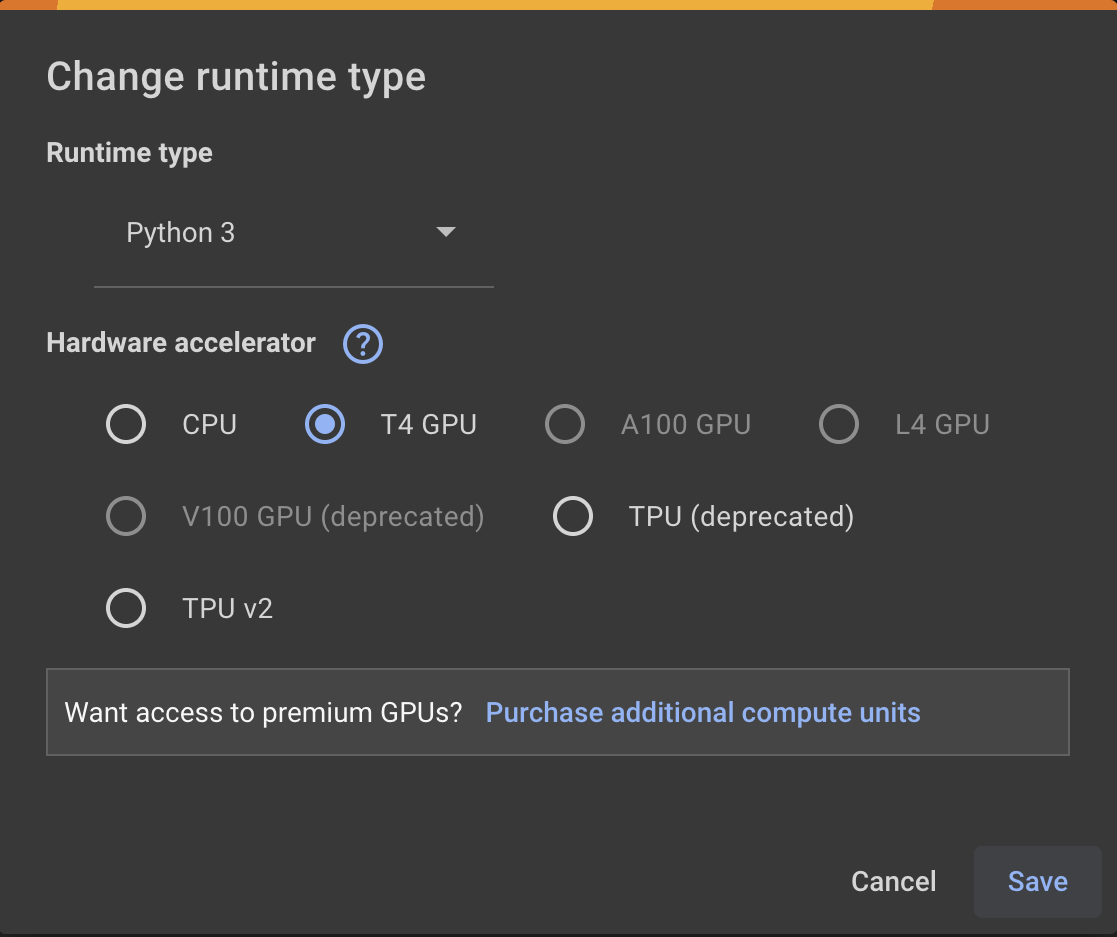

It might be a good idea to first work on a CPU with a slice of the dataset until your code works without problems. Then you can switch to a GPU runtime and work on the whole dataset. Notice that you will have to run all the cells again as the change of the runtime will effectively start a fresh session.

⚠️ **Disclaimer**: Google Colab provides free access to GPUs, but this comes with limitations. Sessions are time-limited (typically ~12 hours), resources are shared (you might not always get access to a GPU) and idle notebooks can be disconnected. If you're using Colab Pro or Pro+, the limits are more relaxed but still not unlimited. Be mindful of these constraints when planning long-running experiments or training large models. Since you're working in a group, you should be able to access up to 3 accounts — keep this in mind as you plan your work.

If you have a GPU locally, you don't need to do that, and you can work on the whole dataset from the get go.

To select a portion of the dataset uncomment the following cell. Make sure to comment it again when you are ready to run the notebook on the notebook on the GPU.

In [55]:
#test_ds = test_ds.select(range(5000))

<a name='e8'></a>
### Exercise 8 Tokenize sentence and compressed
(2p) We will first tokenize the dataset. Write two functions that will tokenize the two columns - `sentence` and `compressed` - separately. Do not use padding when tokenizing, as we will later use [DataCollator](https://huggingface.co/docs/transformers/en/main_classes/data_collator) to "pack and pad" the examples to form batches.

If you have any doubts please check the following [tutorial](https://huggingface.co/docs/datasets/use_dataset) on Huggingface.

In [56]:
def tokenize_sentence(examples):
    """
    Tokenizes the `sentence` column from the batch of examples and returns the whole output of the tokenizer.
    Args:
        examples: a batch of examples

    Returns: the tokenized `sentence` column (returns the whole output of the tokenizer)

    """
    ### YOUR CODE HERE

    sentences = examples['sentence']
    
    tokenized_sentence = tokenizer(sentences, padding=False,truncation=True, return_tensors='np')

    ### YOUR CODE ENDS HERE
    return tokenized_sentence


def tokenize_compressed(examples):
    """
    Tokenizes the `compressed` column from the batch of examples and returns the whole output of the tokenizer.
    Args:
        examples: a batch of examples

    Returns: the tokenized `compressed` column (returns the whole output of the tokenizer)

    """

    ### YOUR CODE HERE

    compressed_sentence = examples['compressed']

    tokenized_compressed = tokenizer(compressed_sentence, padding=False, return_tensors='np')

    ### YOUR CODE ENDS HERE
    return tokenized_compressed

In the next cell, we will apply the functions that you implemented on the dataset (using `map()` method). We will do it twice to obtain two separate datasets for full and compressed sentence each. Notice that we drop the original columns when we form the new datasets.

In [57]:
tokenized_sentence_ds = test_ds.map(tokenize_sentence, batched=True, remove_columns=['sentence', 'compressed'])
print(tokenized_sentence_ds)

tokenized_compressed_ds = test_ds.map(tokenize_compressed, batched=True, remove_columns=['sentence', 'compressed'])
print(tokenized_compressed_ds)

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36000
})


Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36000
})


Let's examine the first few examples from both datasets. Make sure that they make sense to you.

In [58]:
print(tokenized_sentence_ds[0:3])
print(tokenized_compressed_ds[0:3])

{'input_ids': [[101, 1037, 2152, 1011, 5464, 2845, 5768, 2880, 2758, 4924, 2003, 4941, 2000, 16625, 4895, 11733, 14621, 2140, 17147, 2114, 4238, 2058, 2049, 4517, 2943, 2565, 1012, 102], [101, 1037, 2280, 2307, 4212, 3664, 2040, 12254, 2053, 5049, 2000, 15016, 1011, 3141, 1998, 27208, 5571, 2758, 2002, 2097, 5574, 1996, 2028, 1011, 2095, 7173, 6251, 2002, 2363, 3041, 2023, 3204, 1012, 102], [101, 2745, 1039, 1012, 2534, 2496, 2010, 2522, 1011, 2732, 2006, 1996, 2265, 7673, 10533, 1999, 1037, 2047, 2095, 1005, 1055, 6574, 5103, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In the following cell you can find the function that will apply the provided sentence embedding function to the dataset. It uses the DataCollator we metioned earlier (you are welcome to check the documentation: [https://huggingface.co/docs/transformers/en/main_classes/data_collator](https://huggingface.co/docs/transformers/en/main_classes/data_collator)).

In [59]:
from torch.utils.data.dataloader import DataLoader

def embed_dataset(dataset, model, sentence_embedding_fn, batch_size=8):
    data_collator = transformers.DataCollatorWithPadding(tokenizer)
    data_loader = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator)
    sentence_embeddings = []
    with torch.no_grad():
        for batch in tqdm.tqdm(data_loader):
            batch.to(device)
            model_output = model(**batch, output_hidden_states=True)
            batch_sentence_embeddings = sentence_embedding_fn(batch, model_output)
            sentence_embeddings.append(batch_sentence_embeddings.detach().cpu())

    sentence_embeddings = torch.concat(sentence_embeddings, dim=0)
    return sentence_embeddings

We will embed the dataset containing sentences by using the function from the previous cell. We will pass your `calculate_sentence_embeddings` function. By default, this function uses the hidden representations of the last layer.

If you are not using a GPU this can take some time depending on your system and your implementation.

To use different layer you can pass different value for the `layer` parameter using python's `functools.partial` function ([https://docs.python.org/3/library/functools.html#functools.partial](https://docs.python.org/3/library/functools.html#functools.partial)).

In [61]:
sentence_embeddings = embed_dataset(tokenized_sentence_ds, model, calculate_sentence_embeddings)
print(sentence_embeddings.shape)

100%|███████████████████████████████████████| 4500/4500 [07:17<00:00, 10.29it/s]


torch.Size([36000, 768])


The following cell will embed the compressed sentences. Make sure to pass the same function for calculating the sentence embeddings.

In [77]:
compressed_embeddings = embed_dataset(tokenized_compressed_ds, model, calculate_sentence_embeddings)
print(compressed_embeddings.shape)

100%|███████████████████████████████████████| 4500/4500 [04:24<00:00, 17.03it/s]


torch.Size([36000, 768])


## 4. Retrieving Sentences

Guess what? We are going to try the same task/dataset as the previous lab and hopefully get better performance.

As a reminder, we will be using vector representations (based on the BERT embeddings) to retrieve only the relevant ones based on some user query. It is similar to the a search retrieval task (based on what we discussed in the relevant lecture) where a user provides a query (that is the compressed sentence) and the system returns the sentences that are more similar to the query.

In the information retrieval lecture, we discussed how to solve this retrieval problem by using bag-of-words as a representation basis. In Lab 2, we solved the problem using static word embeddings (learned from our corpus) and by averaring their equivalent vectors per sentence. Now, we are going to use the BERT model (we loaded above) to get contextualized sentence embeddings! Are you as excited as we are?

<a name='e9'></a>
### Exercise 9 Embed query function

(1p) First step to a retrieval task is to embed the query (aka find a proper vector representation). We will do it the same way as we did it in the previous exercises. Complete the following function to return the embedding of the provided text.

In [78]:
def embed_query(query, sentence_embedding_fn):
    """
    Embeds the provided query using the model and the `sentence_embedding_fn` function
    Args:
        query: a str with the query
        sentence_embedding_fn: the function used to embed the sentence based on the input and output of the model

    Returns: a PyTorch tensor with the embedded query

    """

    #### YOUR CODE HERE

    query_tokenized = tokenizer(query, padding=True, return_tensors='pt')
    model_output = model(**query_tokenized, output_hidden_states=True)
    
    ### YOUR CODE ENDS HERE

    query_embedding = sentence_embedding_fn(query_tokenized, model_output)

    return query_embedding.detach().cpu()


Next we will embed the query (which is the same as in the previous lab). What is the dimensionality of the embedding?

In [79]:
query = "volcano erupted"
print(query)

query_embedding = embed_query(query, calculate_sentence_embeddings)
print(query_embedding.shape)
#print(query_embedding)

volcano erupted
torch.Size([1, 768])


<a name='e10'></a>
### Exercise 10 ========== 1 to n in PyTorch

(3p) The next step in our retrieval system, would be to calculate the proximity of a query to our retrieval corpus (in our case that is all the sentences).

Complete the following function to calculate the cosine similarity between a vector (first parameter `vector`, that will usually be the query vector) and all other vectors (second parameter `other_vectors`, that will be the sentence embeddings in our case).

The corresponding function from the previous lab would actually work without changes, as PyTorch's tensors are automatically cast into numpy arrays. That said, convert the function into PyTorch to see how the two libraries are similar to each other.

Note that the `other_vectors` parameter is a single PyTorch tensor of size `N x D`, where $N$ is the number of vectors and $D$ is the dimension of each vector.

In [80]:
def cosine_similarity_1_to_n(vector, other_vectors):
    """
    Calculates the cosine similarity between a single vector and other vectors.
    Args:
        vector: a tensor representing a vector of D dimensions
        other_vectors: a 2D tensor representing other vectors (of the size NxD, where N is the number of vectors and D is their dimension)

    Returns: a 1D numpy array of size N containing the cosine similarity between the vector and all the other vectors

    """

    #### YOUR CODE HERE
    dot_products = torch.matmul(other_vectors, vector)
    norm_vector = torch.linalg.norm(vector)
    norm_other_vectors = torch.linalg.norm(other_vectors, dim=1)
    similarity = dot_products / (norm_vector * norm_other_vectors + 1e-8)

    return similarity.numpy()

    ### YOUR CODE ENDS HERE

We will use the function to calculate the similarity of all sentences in the dataset to our query.

In [81]:
query_similarity = cosine_similarity_1_to_n(query_embedding[0], sentence_embeddings)
print(query_similarity.shape)
print(query_similarity[:10])

(36000,)
[0.45532292 0.4396876  0.3860733  0.38955238 0.4340558  0.45294917
 0.47203687 0.42783117 0.41067877 0.43687636]


The following cell will select the most similar sentence.

In [82]:
most_similar = int(np.argmax(query_similarity))
print(most_similar)
print(query_similarity[most_similar])
print(test_ds[most_similar]['sentence'])

22111
0.6207303
US Geological Survey says a 6.1 aftershock rattles Haiti early Wednesday morning shaking building and sending people screaming into the streets.


The following function will return the indices of the top-k elements in the array.

In [83]:
def top_k_indices(array, k, sorted=True):
    """
    Returns top-k indices from the 1D array. If `sorted` is `True` the returned indices are sorted in the descending order
    Args:
        array: a 1D numpy array
        k: a number of top indices to return
        sorted: if True, the returned indices are sorted in descending order

    Returns: a 1D array containing top-k indices

    """
    top_k = np.argpartition(array, -k)[-k:]
    if sorted:
        selected = array[top_k]
        sorted_selected = (-selected).argsort()
        top_k = top_k[sorted_selected]
    return top_k

In [84]:
top_indices = top_k_indices(query_similarity, k=10).tolist()
for idx in top_indices:
    print(split_ds['test'][idx]['sentence'])
    print(f'similarity: {query_similarity[idx]}')

US Geological Survey says a 6.1 aftershock rattles Haiti early Wednesday morning shaking building and sending people screaming into the streets.
similarity: 0.6207302808761597
Wind causes problems during house fire fight near SW 52nd and Monte.
similarity: 0.6033093929290771
Scientists have discovered a magmatically triggered slow earthquake at Kilauea Volcano in Hawaii.
similarity: 0.6021327972412109
Education Department fined $50,000 over school accident which left a teenage girl with permanent injuries.
similarity: 0.5949341654777527
An earthquake measuring 4.3 on Richter scale jolted surrounding areas of Mousian in Iranian western province of Ilam and close to Iraqi border on Tuesday evening, IRNA reported.
similarity: 0.580365777015686
Investigation into Springboro plane crash continues as victims are remembered.
similarity: 0.5799497961997986
A sinkhole nearly swallowed a century old Iowa home causing the house to slide off its foundation.
similarity: 0.5782404541969299
A flurry 

<a name='e11'></a>
### Exercise 11 Experiment with different queries

(10p) Experiment with different queries (taking into account the nature of the dataset and your insights from the analysis so far).
Try at least 5 different queries and analyze top 5 most similar responses. 

Does the search perform well? When does it fail? Provide reasons for the good/bad result in each case. 

Optionally, if you completed the previous lab, try the examples from that case. What do you observe?

In [72]:
#### YOUR CODE HERE

queries = [
    # The meaning of queries was not preserved, both have postivie sentiment, but 
    "DRUNK neighbour attacked a woman","DRUNK woman attacked a neighbour",
    # The ordering of the words in queries, changes the contex, and this is visible in the simillarity scoring, 
    # although queries are very simillar the search performs better then BOW or tf.idf methods. It does assing higer smiliarity 
    # score to correct sentence-querry pair "A DRUNK woman attacked a neighbour with a..." 0.84 while for the other pair 0.79
    # It also preserves context for the fact that it's the women gets attacked in the second pair and returns sentence "woman assaulted by man who broke into..." with score 0.83
    # all 10 sentences for both queries preserve the context of the, something bad happening to a women or something bad happening to a neigbhour ( man ) ex: " A man walking in the road was hit and..."
    "the weather is good","the weather is bad",
    # The query sentiment for wheather is preserverd, 4 out of 5 top sentences for query the weather is good where about positive wheather events. For the query with negatvie 
    # sentiment the returned sentences were about unpleasant whether events like snow drought. In both cases there were sentences that were contextually further from queries,
    #  like  "What time of the day is best for hunting deer during a full moon?"
    "suddenly I'm dreaming of...bacon",
    # We can observe score of 96 for simillarity, between the query and "I'm dreaming of...bacon.", which compares worse to tf.idf 
] 
for i, query in enumerate(queries):
    query_embedding = embed_query(query, calculate_sentence_embeddings)
    query_similarity = cosine_similarity_1_to_n(query_embedding[0], sentence_embeddings)
    top_indices = top_k_indices(query_similarity, k=5).tolist()
    print(f"\n--- Results for Query: \"{query}\" ---")
    for idx in top_indices:
        print(split_ds['test'][idx]['sentence'])
        print(f'similarity: {query_similarity[idx]}')
    print(f"\n")

### YOUR CODE ENDS HERE


--- Results for Query: "DRUNK neighbour attacked a woman" ---
A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
similarity: 0.7957147359848022
A Brighton man accused of attacking a teenager while she was in the shower pleaded guilty to burglary in court Thursday.
similarity: 0.7705990672111511
A ROBBER stole cash from a shop till this week after threatening a member of staff.
similarity: 0.7674857974052429
A girl was knocked unconscious and robbed during a terrifying attack on a busy Preston road.
similarity: 0.764498233795166
A PREGNANT woman was kicked in the stomach by a teenage girl in a street brawl.
similarity: 0.7568811178207397



--- Results for Query: "DRUNK woman attacked a neighbour" ---
A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
similarity: 0.8392162322998047
A ROBBER stole cash from a shop till this week after threatening a member of staff.
similarity: 0.8110705614089966
A girl was knocked

## 5. Evaluating Retrieval

In this section (as with the previous lab) we will try to evaluate how good our sentence retrieval system is. To keep the computational resources manageable, we will use the test set for that as its size is more manageable.

Recall from the lecture in IR that there are several metrics to evaluate retrieval performance by taking into account the relevance of the retrieved results to the query. We will use Recall@K here (for more metrics and more details refer to the lecture slides and the textbooks).

RRecall@K is a metric used to measure the effectiveness of a search system in retrieving relevant documents within the top $K$ retrieved documents. It calculates the proportion of relevant documents retrieved within the top-$K$ results, compared to the total number of relevant documents in the collection.

$
\text{Recall@K} = \frac{\text{Number of relevant documents retrieved in the top }-K}{\text{Total number of relevant documents}}
$

In our case, we have a sentence, and it's compressed version. To test our system, we will treat compressed sentences as the queries. Each query will have only a single relevant sentence - the corresponding uncompressed sentence.

Therefore, for the calculation of Recall@K we will take into account whether the correct retrieved result is contained within the first $K$ retrieved results. For example, if for a query (i.e. a compressed sentence) we retrieve 10 results and within these we see the relevant one (i.e. the full sentence), then Recall@10 = 1.

<a name='e12'></a>
### Exercise 12 Cosine similarity m to n in PyTorch

(3p) In this exercise you will revisit your implementation of the cosine siliarity. Generalize it so that it can accept two PyTorch tensors containing two sets of vectors (first one containing $M$ vectors and the second one $N$ vectors). Compute the cosine similarity between each pair of vectors coming from the two sets. The result should be a tensor of size $M x N$.

Once again, try to write an efficient code. This means no loops. Remember the relation between matrix multiplication and dot product. (Depending on your implementation of the previous function calculating cosine similarity, this one can be almost the same)

In [73]:
def cosine_similarity_m_to_n(vectors, other_vectors):
    """
    Calculates the cosine similarity between a multiple vectors and other vectors.
    Args:
        vectors: a numpy array representing M number of vectors of D dimensions (of the size MxD)
        other_vectors: a 2D numpy array representing other vectors (of the size NxD, where N is the number of vectors and D is their dimension)

    Returns: a numpy array of cosine similarity between all the vectors and all the other vectors

    """

    #### YOUR CODE HERE

    vectors = vectors.float()
    other_vectors = other_vectors.float()

    # Compute dot products (MxN matrix)
    dot_products = torch.matmul(vectors, other_vectors.transpose(0, 1))

    # Compute norms of each vector
    norm_vectors = torch.norm(vectors, p=2, dim=1)
    norm_other_vectors = torch.norm(other_vectors, p=2, dim=1)

    # Compute the product of norms for each pair (MxN matrix)
    norm_products = norm_vectors.unsqueeze(1) * norm_other_vectors.unsqueeze(0)

    # Add a small epsilon to prevent division by zero for zero vectors
    epsilon = 1e-8
    similarity = dot_products / (norm_products + epsilon)
    similarity = torch.clamp(similarity, -1.0, 1.0)

    return similarity

    ### YOUR CODE ENDS HERE

The following function will use your implementation to calculate Recall@K based on the similarity matrix.

In [74]:
def calculate_recall(queries, sentences, k, batch_size=1000):
    """
    Calculates recall@k given the embeddings of the queries and sentences.
    Assumes that only a single sentence with the same index as query is relevant.
    Batching is implemented to avoid high memory usage.
    Args:
        queries: a numpy array with the embeddings of N queries
        sentences: a numpy array with the embeddings of N sentences available for retrieval
        k: number of top results to search for the relevant sentence
        batch_size: number of queries to process at a time

    Returns: calculated recall@k

    """
    n_queries = queries.shape[0]
    correct = np.zeros(n_queries, dtype=bool)

    with tqdm.tqdm(total=n_queries) as pbar:
        for batch_start in range(0, n_queries, batch_size):
            batch_end = min(batch_start + batch_size, n_queries)
            queries_batch = queries[batch_start:batch_end]
            batch_similarity = cosine_similarity_m_to_n(queries_batch, sentences)

            for i, similarity_row in enumerate(batch_similarity):
                query_index = batch_start + i
                top_k = top_k_indices(similarity_row, k=k, sorted=False)

                if query_index in top_k:
                    correct[query_index] = True

                pbar.update(1)

    recall = np.sum(correct) / n_queries
    return recall

You can use it like so:

In [75]:
recall_at_1 = calculate_recall(compressed_embeddings, sentence_embeddings, k=1, batch_size=1000)
print(f'\n{recall_at_1 * 100:.2f}%')

100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2775.69it/s]


50.79%


<a name='e13'></a>
### Exercise 13 Recal for different k-s

Calculate recall for different values of $K$ (at least 5 different values). Comment on how recall changes based on the value of $K$. Are the results expected or surprising? At this stage, do not experiment further. That will come in the next Sections which are more open ended.

In [76]:
#### YOUR CODE HERE

k_values = [1, 5, 10, 20, 50, 100,1000,10000]

# Calculate Recall@K for each value of K
print("Calculating Recall@K for different K values:")
recall_results = {}
for k in k_values:
    recall = calculate_recall(compressed_embeddings, sentence_embeddings, k=k, batch_size=1000)
    recall_results[k] = recall
    print(f"Recall@{k}: {recall * 100:.2f}%")



# --- Comment on the results ---
# The commentary states that Recall@K consistently increases or stays the same as K increases, which is expected by definition. 
# Since Recall@K measures if a relevant item is in the top K results and, in this case, there's only one relevant item per query,
# a higher K simply provides a larger window to find that item in the ranked list. 
# This increase demonstrates that while the single relevant sentence might not always be the top result, 
# it is likely to be found within the expanded set of top results as K grows.


### YOUR CODE ENDS HERE

Calculating Recall@K for different K values:


100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2796.79it/s]


Recall@1: 50.79%


100%|███████████████████████████████████| 36000/36000 [00:16<00:00, 2229.29it/s]


Recall@5: 67.44%


...

Recall@100: 88.58%


100%|███████████████████████████████████| 36000/36000 [00:16<00:00, 2144.75it/s]


Recall@1000: 96.78%


100%|███████████████████████████████████| 36000/36000 [00:20<00:00, 1745.22it/s]

Recall@10000: 99.49%


## 6. Pushing the performance: Modifying the sentence embeddings


<a name='e14'></a>
### Exercise 14 Different ways of embedding sentences

(10p) Experiment with the way the sentence embedding is calculated and check performance on the task. For example, you can try using the embedding of the `CLS` token or averaging the hidden states of different layer or even averaging the representations of several layers. The choice is yours, but make sure to give a justification of your choice, based on the results and your inspection of the dataset. 

Inspect the representations of tokens and sentences.

Evaluate the modification on the sentence retrieval task.

In [97]:
#### YOUR CODE HERE


# Strategy 1: CLS token embedding from last hidden layer
def cls_token_embedding(input_batch, model_output):
    return model_output['hidden_states'][-1][:, 0]

# Strategy 2: Mean pooling of last hidden layer
def mean_pooling_last_layer(input_batch, model_output):
    last_hidden = model_output['hidden_states'][-1]
    attention_mask = input_batch['attention_mask']
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    return torch.sum(last_hidden * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

# Strategy 3: Mean pooling across last 4 hidden layers
def mean_pooling_last_4_layers(input_batch, model_output):
    stacked = torch.stack(model_output['hidden_states'][-4:])  # (4, B, T, D)
    mean_hidden = torch.mean(stacked, dim=0)  # (B, T, D)
    attention_mask = input_batch['attention_mask']
    mask = attention_mask.unsqueeze(-1).expand(mean_hidden.size()).float()
    return torch.sum(mean_hidden * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

# Embedding runner
def embed_all_strategies(tokenized_ds, model, tokenizer):
    collator = DataCollatorWithPadding(tokenizer)
    loader = DataLoader(tokenized_ds, batch_size=8, collate_fn=collator)

    # --- Inspection on first batch ---
    sample = next(iter(loader))
    sample = {k:v.to(device) for k,v in sample.items()}
    with torch.no_grad():
        out = model(**sample, output_hidden_states=True)
    print("=== INSPECTION ===")
    print(" input_ids shape:       ", sample['input_ids'].shape)           # (8, T)
    print(" last_hidden_state shape:", out.last_hidden_state.shape)         # (8, T, 768)
    print(" # hidden_states layers: ", len(out.hidden_states))             # e.g. 13
    print(" first 3 tokens, dims0–4:\n", out.last_hidden_state[0,:3,:5].cpu().numpy())
    print(" CLS embedding dims0–4:  ", out.last_hidden_state[0,0,:5].cpu().numpy())
    print("====================\n")

    embeddings = {'cls': [], 'mean_last': [], 'mean_last4': []}
    with torch.no_grad():
        for batch in tqdm.tqdm(loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            output = model(**batch, output_hidden_states=True)

            embeddings['cls'].append(cls_token_embedding(batch, output).cpu())
            embeddings['mean_last'].append(mean_pooling_last_layer(batch, output).cpu())
            embeddings['mean_last4'].append(mean_pooling_last_4_layers(batch, output).cpu())

    return {
        k: torch.cat(v, dim=0) for k, v in embeddings.items()
    }

# Example usage:
sentence_embeds = embed_all_strategies(tokenized_sentence_ds, model, tokenizer)
compressed_embeds = embed_all_strategies(tokenized_compressed_ds, model, tokenizer)




=== INSPECTION ===
 input_ids shape:        torch.Size([8, 44])
 last_hidden_state shape: torch.Size([8, 44, 768])
 # hidden_states layers:  13
 first 3 tokens, dims0–4:
 [[ 0.01445213  0.00899917 -0.3316019  -0.3589843  -0.18942316]
 [-0.05259338 -0.12401631 -0.44809347 -0.41334617 -0.26303238]
 [-0.10502277  0.1103867  -0.2477009  -0.18734208 -0.42727262]]
 CLS embedding dims0–4:   [ 0.01445213  0.00899917 -0.3316019  -0.3589843  -0.18942316]



100%|███████████████████████████████████████| 4500/4500 [05:38<00:00, 13.30it/s]


=== INSPECTION ===
 input_ids shape:        torch.Size([8, 16])
 last_hidden_state shape: torch.Size([8, 16, 768])
 # hidden_states layers:  13
 first 3 tokens, dims0–4:
 [[-0.20124157 -0.03470434 -0.16367692 -0.36001265 -0.1426317 ]
 [-0.07149272 -0.0658253  -0.3846143  -0.16522416  0.21544276]
 [-0.25607127  0.00539284 -0.11708394 -0.20866498 -0.46535403]]
 CLS embedding dims0–4:   [-0.20124157 -0.03470434 -0.16367692 -0.36001265 -0.1426317 ]



100%|███████████████████████████████████████| 4500/4500 [03:48<00:00, 19.68it/s]


In [89]:
# Evaluate the strategies using the recall method
k_values = [1, 5, 10]

for method in ['cls', 'mean_last', 'mean_last4']:
    print(f"\n--- Evaluating strategy: {method} ---")
    recalls = []
    for k in k_values:
        recall = calculate_recall(
            queries=torch.tensor(compressed_embeds[method]),
            sentences=torch.tensor(sentence_embeds[method]),
            k=k,
            batch_size=1000
        )
        recalls.append((k, recall))
        print(f"Recall@{k}: {recall * 100:.2f}%")
### YOUR CODE ENDS HERE

/var/folders/h6/5112162d7p9566r48ypkx9d00000gn/T/ipykernel_33984/1437323044.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries=torch.tensor(compressed_embeds[method]),
/var/folders/h6/5112162d7p9566r48ypkx9d00000gn/T/ipykernel_33984/1437323044.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sentences=torch.tensor(sentence_embeds[method]),



--- Evaluating strategy: cls ---


100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2791.23it/s]


Recall@1: 10.82%


100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2940.39it/s]


...

Recall@1: 45.07%


100%|███████████████████████████████████| 36000/36000 [00:20<00:00, 1728.86it/s]


Recall@5: 61.83%


100%|███████████████████████████████████| 36000/36000 [00:27<00:00, 1322.39it/s]

Recall@10: 68.15%


## Pushing the performance: Trying different models



<a name='e15'></a>
### Exercise 15 Different model

(15p) In this exercise you are asked to try other BERT-like model from huggingface. You can consider the MSMARCO model [here](https://huggingface.co/sentence-transformers/msmarco-bert-base-dot-v5). Make sure to read the model card on the huggingface website in order to understand how to use it. You don't need to install `sentence-transformers`.

As before, inspect the the representations of tokens and sentences. 

Evaluate the model on sentence retrieval.

In [96]:
#### YOUR CODE HERE
from transformers import AutoTokenizer, AutoModel


# 1. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load MSMARCO BERT model & tokenizer
model_name = "sentence-transformers/msmarco-bert-base-dot-v5"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# 3. Function to compute normalized CLS embeddings
def get_cls_embeddings(texts, batch_size=32):
    all_embeds = []
    for i in tqdm.trange(0, len(texts), batch_size, desc="Encoding"):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            cls = outputs.last_hidden_state[:, 0]            # [CLS] token
            cls = torch.nn.functional.normalize(cls, p=2, dim=1)
        all_embeds.append(cls.cpu())
    return torch.cat(all_embeds, dim=0)

# 4. Inspect token‐ and sentence‐level representations
sample = test_ds["sentence"][0]
enc = tokenizer(sample, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**enc)

print("Token embeddings shape:", out.last_hidden_state.shape)
print("First 3 token embeddings (first 5 dims):\n",
      out.last_hidden_state[0, :3, :5].cpu().numpy())
print("Sentence CLS embedding (first 5 dims):\n",
      out.last_hidden_state[0, 0, :5].cpu().numpy())

# 5. Prepare a smaller subset for evaluation
compressed_texts = test_ds["compressed"]
sentence_texts   = test_ds["sentence"]

# 6. Generate embeddings
compressed_embeds = get_cls_embeddings(compressed_texts)
sentence_embeds   = get_cls_embeddings(sentence_texts)

print("Compressed embeds shape:", compressed_embeds.shape)
print("Sentence   embeds shape:", sentence_embeds.shape)

# 7. Convert to NumPy and evaluate Recall@K
compressed_np = compressed_embeds
sentence_np   = sentence_embeds

k_values = [1, 5, 10]
for k in k_values:
    recall = calculate_recall(compressed_np, sentence_np, k=k, batch_size=500)
    print(f"Recall@{k}: {recall*100:.2f}%")


Token embeddings shape: torch.Size([1, 28, 768])
First 3 token embeddings (first 5 dims):
 [[ 0.01445213  0.00899917 -0.3316019  -0.3589843  -0.18942316]
 [-0.05259338 -0.12401631 -0.44809347 -0.41334617 -0.26303238]
 [-0.10502277  0.1103867  -0.2477009  -0.18734208 -0.42727262]]
Sentence CLS embedding (first 5 dims):
 [ 0.01445213  0.00899917 -0.3316019  -0.3589843  -0.18942316]


Encoding: 100%|█████████████████████████████| 1125/1125 [06:01<00:00,  3.12it/s]


Compressed embeds shape: torch.Size([36000, 768])
Sentence   embeds shape: torch.Size([36000, 768])


100%|███████████████████████████████████| 36000/36000 [00:09<00:00, 3748.45it/s]


Recall@1: 89.67%


100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2898.04it/s]


Recall@5: 95.50%


100%|███████████████████████████████████| 36000/36000 [00:12<00:00, 2890.92it/s]

Recall@10: 96.48%


### Exercise 16 Comparison between models

(10p) Compare the models you used in this lab (and optionally the previous lab if you completed it). Discuss the results and the potential benefits and drawbacks of each method.

I re-ran each model’s embedding step in that snippet just to keep the example self-contained:

In [98]:
#### YOUR CODE HERE

# --- 1) Lab 2 model: BAAI/bge-small-en ---

tokenizer_bge = AutoTokenizer.from_pretrained("BAAI/bge-small-en")
model_bge     = AutoModel.from_pretrained("BAAI/bge-small-en").to(device)
model_bge.eval()

def embed_bge(tokenized_ds, batch_size=32):
    """CLS‐embedding runner for BGE model."""
    collator = DataCollatorWithPadding(tokenizer_bge)
    loader   = DataLoader(tokenized_ds, batch_size=batch_size, collate_fn=collator)
    all_embs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(loader, desc="BGE Embedding"):
            batch = {k: v.to(device) for k,v in batch.items()}
            out   = model_bge(**batch)
            cls   = out.last_hidden_state[:, 0]                           # [CLS]
            cls   = torch.nn.functional.normalize(cls, p=2, dim=1)
            all_embs.append(cls.cpu())
    return torch.cat(all_embs, dim=0)

# --- 2) BERT-base model (mean-pooling over last layer) ---

tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
model_bert     = AutoModel.from_pretrained("bert-base-uncased").to(device)
model_bert.eval()

def mean_pooling_last_layer(batch, out):
    last = out.last_hidden_state                # (B, T, D)
    mask = batch["attention_mask"].unsqueeze(-1) # (B, T, 1)
    summed = (last * mask).sum(dim=1)            # (B, D)
    counts = mask.sum(dim=1).clamp(min=1e-9)      # (B, 1)
    return summed / counts                       # (B, D)

def embed_bert(tokenized_ds, embed_fn, batch_size=8):
    collator = DataCollatorWithPadding(tokenizer_bert)
    loader   = DataLoader(tokenized_ds, batch_size=batch_size, collate_fn=collator)
    all_embs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(loader, desc="BERT Embedding"):
            batch = {k: v.to(device) for k,v in batch.items()}
            out   = model_bert(**batch, output_hidden_states=True)
            emb   = embed_fn(batch, out)
            all_embs.append(emb.cpu())
    return torch.cat(all_embs, dim=0)

# --- 3) MSMARCO-BERT model (CLS token) ---

tokenizer_ms = AutoTokenizer.from_pretrained("sentence-transformers/msmarco-bert-base-dot-v5")
model_ms     = AutoModel.from_pretrained("sentence-transformers/msmarco-bert-base-dot-v5").to(device)
model_ms.eval()

def embed_ms(tokenized_ds, batch_size=32):
    collator = DataCollatorWithPadding(tokenizer_ms)
    loader   = DataLoader(tokenized_ds, batch_size=batch_size, collate_fn=collator)
    all_embs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(loader, desc="MSMARCO Embedding"):
            batch = {k: v.to(device) for k,v in batch.items()}
            out   = model_ms(**batch)
            cls   = out.last_hidden_state[:, 0]
            cls   = torch.nn.functional.normalize(cls, p=2, dim=1)
            all_embs.append(cls.cpu())
    return torch.cat(all_embs, dim=0)

# --- Generate embeddings for each model ---

print("Embedding with BGE model...")
bge_q = embed_bge(tokenized_compressed_ds)
bge_s = embed_bge(tokenized_sentence_ds)

print("Embedding with BERT-base (mean_last)...")
bert_q = embed_bert(tokenized_compressed_ds, mean_pooling_last_layer)
bert_s = embed_bert(tokenized_sentence_ds,   mean_pooling_last_layer)

print("Embedding with MSMARCO-BERT...")
ms_q   = embed_ms(tokenized_compressed_ds)
ms_s   = embed_ms(tokenized_sentence_ds)

# --- evaluate Recall@K ---

bge_q_np  = bge_q ;  bge_s_np  = bge_s 
bert_q_np = bert_q;  bert_s_np = bert_s
ms_q_np   = ms_q;    ms_s_np   = ms_s

for k in (1, 5, 10):
    print(f"\nRecall@{k}:")
    print(f"  BGE model:        {calculate_recall(bge_q_np,  bge_s_np,  k)}")
    print(f"  BERT-base mean:   {calculate_recall(bert_q_np, bert_s_np, k)}")
    print(f"  MSMARCO-BERT CLS: {calculate_recall(ms_q_np,   ms_s_np,   k)}")



### YOUR CODE ENDS HERE

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

  BGE model:        0.9884444444444445


100%|███████████████████████████████████| 36000/36000 [00:15<00:00, 2337.29it/s]


  BERT-base mean:   0.6972777777777778


100%|███████████████████████████████████| 36000/36000 [00:17<00:00, 2074.46it/s]

  MSMARCO-BERT CLS: 0.9647777777777777
